# Task 2: Exploratory Data Analysis
## Customer Churn Analysis and Prediction — SaiKet Systems Data Analysis Internship

**Task:** 2 of 4 (selected tasks)

---

## 1. Business Problem
Before building a predictive model, the business needs to understand **how big the churn problem
is** and **which customer groups churn most**, so that early findings can already guide retention
priorities.

## 2. Objective
Calculate the overall churn rate, explore churn by demographics, tenure, contract type, payment
method, subscribed services, and billing charges, and translate each finding into a business
interpretation.

## 3. Dataset
This notebook uses the cleaned dataset produced in Task 1 (`Task_1_Cleaned_Dataset.csv`).


## 4. Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11


## 5. Load Dataset

In [2]:
df = pd.read_csv('../Task_1_Data_Cleaning_and_Preprocessing/Task_1_Cleaned_Dataset.csv')

# Readable labels for plotting (Churn/binary cols are 0/1 from Task 1 encoding)
df['Churn_Label'] = df['Churn'].map({1: 'Yes', 0: 'No'})
df['gender_Label'] = df['gender'].map({1: 'Male', 0: 'Female'})
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df['Partner_Label'] = df['Partner'].map({1: 'Yes', 0: 'No'})
df['Dependents_Label'] = df['Dependents'].map({1: 'Yes', 0: 'No'})

print(df.shape)
df.head()


(7043, 26)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Label,gender_Label,SeniorCitizen_Label,Partner_Label,Dependents_Label
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,1,Electronic check,29.85,29.85,0,No,Female,No,Yes,No
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,0,Mailed check,56.95,1889.50,0,No,Male,No,No,No
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,1,Mailed check,53.85,108.15,1,Yes,Male,No,No,No
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,0,Bank transfer (automatic),42.30,1840.75,0,No,Male,No,No,No
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,1,Electronic check,70.70,151.65,1,Yes,Female,No,No,No


## 6. Overall Churn Rate

In [3]:
total_customers = len(df)
churned = (df['Churn'] == 1).sum()
retained = (df['Churn'] == 0).sum()
churn_rate = churned / total_customers * 100
retention_rate = retained / total_customers * 100

print(f"Total customers: {total_customers}")
print(f"Churned customers: {churned}")
print(f"Retained customers: {retained}")
print(f"Churn rate: {churn_rate:.2f}%")
print(f"Retention rate: {retention_rate:.2f}%")


Total customers: 7043
Churned customers: 1869
Retained customers: 5174
Churn rate: 26.54%
Retention rate: 73.46%


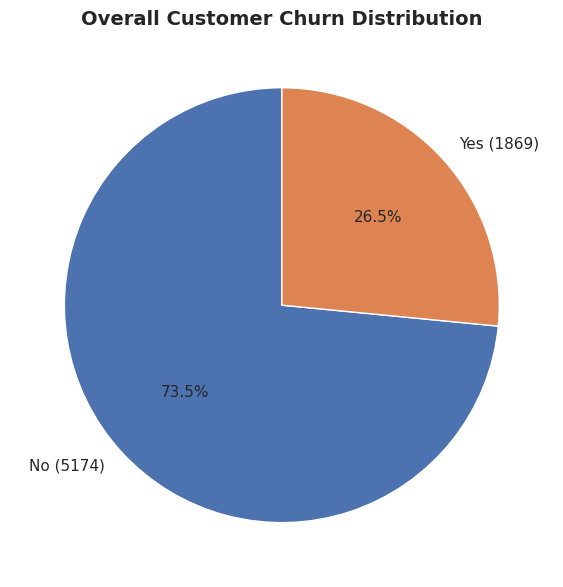

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['Churn_Label'].value_counts()
colors = ['#4C72B0', '#DD8452']
ax.pie(counts, labels=[f"{l} ({v})" for l, v in counts.items()], autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Of 7,043 customers, 1,869 (26.54%) churned and 5,174 (73.46%) were
retained.

**Business Interpretation:** A churn rate of roughly 1 in 4 customers is high for a subscription
business and represents substantial recurring revenue loss. This baseline number is the benchmark
against which every retention strategy in Task 5 should be measured.

## 7. Demographic Analysis

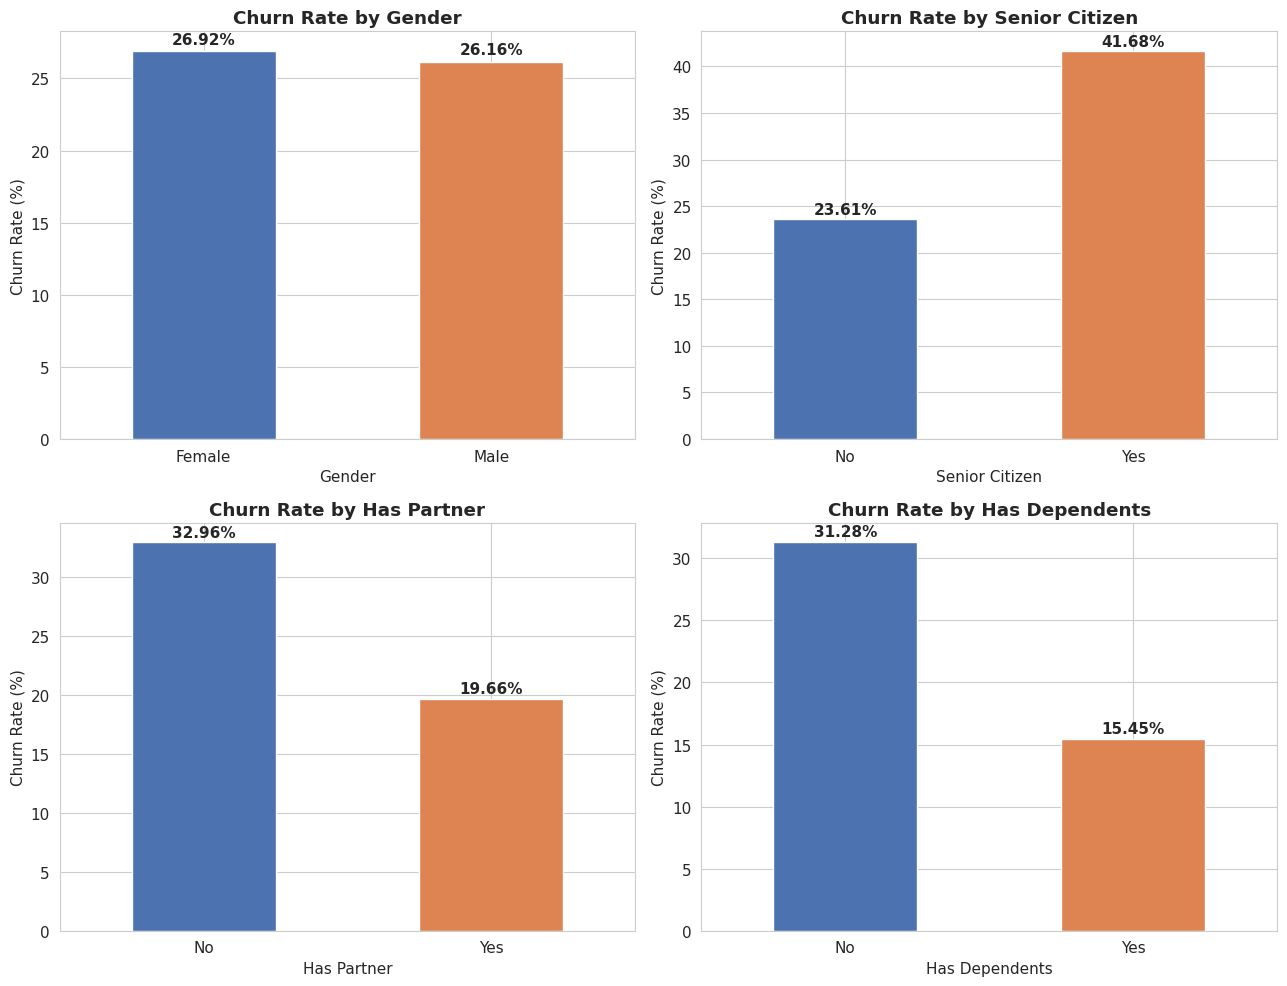


Gender churn rate:
gender_Label
Female    26.92
Male      26.16
Name: Churn, dtype: float64

Senior Citizen churn rate:
SeniorCitizen_Label
No     23.61
Yes    41.68
Name: Churn, dtype: float64

Has Partner churn rate:
Partner_Label
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Has Dependents churn rate:
Dependents_Label
No     31.28
Yes    15.45
Name: Churn, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
demo_cols = [('gender_Label', 'Gender'), ('SeniorCitizen_Label', 'Senior Citizen'),
             ('Partner_Label', 'Has Partner'), ('Dependents_Label', 'Has Dependents')]

for ax, (col, title) in zip(axes.flatten(), demo_cols):
    rate = df.groupby(col)['Churn'].mean().mul(100).round(2)
    rate.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'Churn Rate by {title}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(title)
    ax.tick_params(axis='x', rotation=0)
    for i, v in enumerate(rate):
        ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

for col, title in demo_cols:
    print(f"\n{title} churn rate:")
    print(df.groupby(col)['Churn'].mean().mul(100).round(2))


**Observation:** Gender shows almost no difference in churn (Male vs Female essentially
equal). Senior citizens churn at a noticeably higher rate than non-seniors. Customers without a
partner and customers without dependents both churn substantially more than those with a partner
or dependents.

**Business Interpretation:** Gender is not a useful churn-risk signal and should not drive
retention targeting. Household structure matters more — single customers and customers without
dependents appear less "anchored" to the service and are more price/switch sensitive, which is
useful for tailoring retention offers (e.g. family-bundle incentives).

## 8. Tenure Analysis

In [6]:
print("Tenure statistics (months):")
print(df['tenure'].describe())
print(f"\nMinimum tenure: {df['tenure'].min()}")
print(f"Maximum tenure: {df['tenure'].max()}")
print(f"Mean tenure: {df['tenure'].mean():.2f}")
print(f"Median tenure: {df['tenure'].median():.2f}")


Tenure statistics (months):
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Minimum tenure: 0
Maximum tenure: 72
Mean tenure: 32.37
Median tenure: 29.00


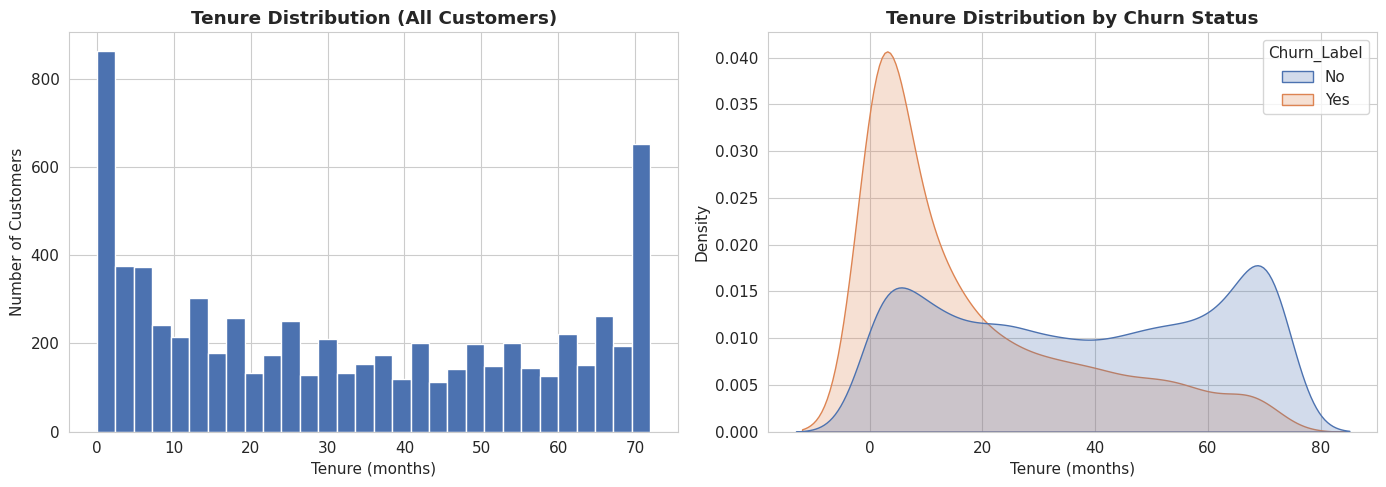

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tenure'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Tenure Distribution (All Customers)', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')

sns.kdeplot(data=df, x='tenure', hue='Churn_Label', fill=True, ax=axes[1],
            palette=['#4C72B0', '#DD8452'], common_norm=False)
axes[1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()


              customer_count  churn_rate_pct
tenure_group                                
0-12                    2186           47.44
13-24                   1024           28.71
25-36                    832           21.63
37-48                    762           19.03
49-60                    832           14.42
61-72                   1407            6.61


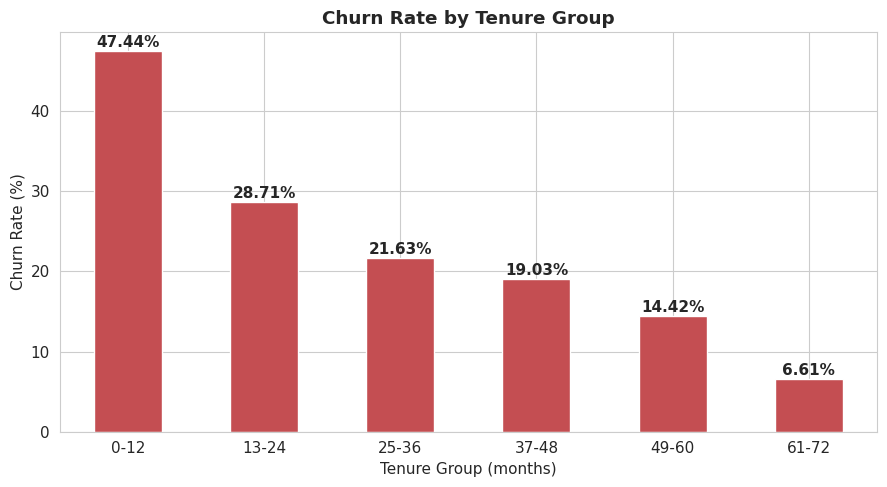

In [8]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].agg(['count', 'mean'])
tenure_churn['mean'] = (tenure_churn['mean'] * 100).round(2)
tenure_churn.columns = ['customer_count', 'churn_rate_pct']
print(tenure_churn)

fig, ax = plt.subplots(figsize=(9, 5))
tenure_churn['churn_rate_pct'].plot(kind='bar', ax=ax, color='#C44E52')
ax.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group (months)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(tenure_churn['churn_rate_pct']):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Tenure ranges from 0 to 72 months (mean ≈ 32.4, median 29). Churn is
sharply concentrated among low-tenure customers (0–12 months) and drops steadily as tenure
increases, with the 61–72 month group churning the least.

**Business Interpretation:** The first year is the highest-risk period for losing a customer. This
strongly supports investing retention effort in an "onboarding window" — the first 12 months —
rather than spreading retention budget evenly across the whole customer base.

## 9. Contract Analysis

                customer_count  churn_rate_pct
Contract                                      
Month-to-month            3875           42.71
One year                  1473           11.27
Two year                  1695            2.83


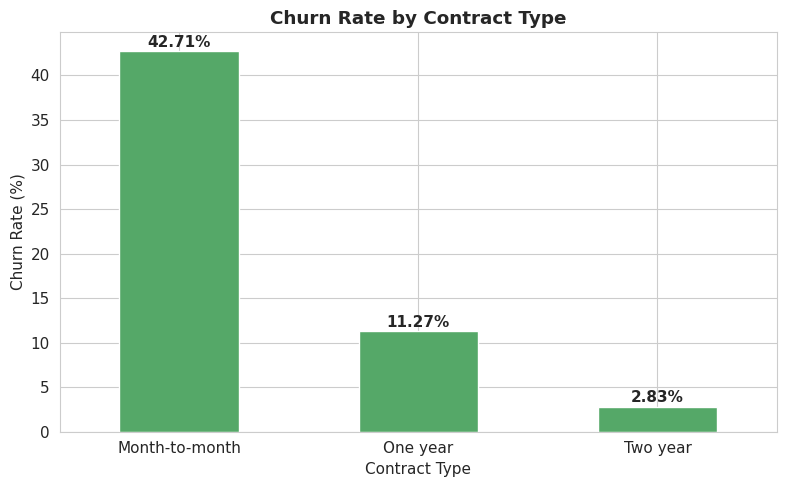

In [9]:
contract_churn = df.groupby('Contract')['Churn'].agg(['count', 'mean'])
contract_churn['mean'] = (contract_churn['mean'] * 100).round(2)
contract_churn.columns = ['customer_count', 'churn_rate_pct']
contract_churn = contract_churn.sort_values('churn_rate_pct', ascending=False)
print(contract_churn)

fig, ax = plt.subplots(figsize=(8, 5))
contract_churn['churn_rate_pct'].plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(contract_churn['churn_rate_pct']):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Month-to-month contracts churn far more than one-year contracts, which
in turn churn more than two-year contracts. Month-to-month is the clear highest-churn contract type.

**Business Interpretation:** Contract length is one of the strongest churn levers the business
directly controls. Incentivizing month-to-month customers to move to a term contract (via discounts
or bundled perks) is a concrete, actionable retention strategy.

## 10. Payment Method Analysis

                           customer_count  churn_rate_pct
PaymentMethod                                            
Electronic check                     2365           45.29
Mailed check                         1612           19.11
Bank transfer (automatic)            1544           16.71
Credit card (automatic)              1522           15.24


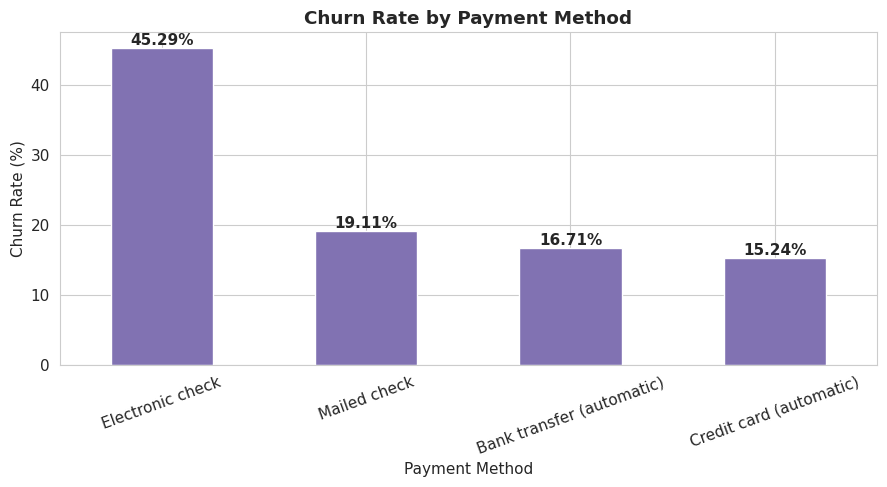

In [10]:
payment_churn = df.groupby('PaymentMethod')['Churn'].agg(['count', 'mean'])
payment_churn['mean'] = (payment_churn['mean'] * 100).round(2)
payment_churn.columns = ['customer_count', 'churn_rate_pct']
payment_churn = payment_churn.sort_values('churn_rate_pct', ascending=False)
print(payment_churn)

fig, ax = plt.subplots(figsize=(9, 5))
payment_churn['churn_rate_pct'].plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('Churn Rate by Payment Method', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Payment Method')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(payment_churn['churn_rate_pct']):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Electronic check has a markedly higher churn rate than the other three
payment methods (bank transfer, credit card, and mailed check are all automatic/manual but
comparatively lower and similar to each other).

**Business Interpretation:** Electronic check is a manual, non-automated payment method — customers
using it are not "locked in" by autopay, and this friction/lack-of-commitment correlates with a much
higher churn rate. Migrating electronic-check customers to automatic payment methods is a low-cost
retention lever worth testing.

## 11. Services Analysis

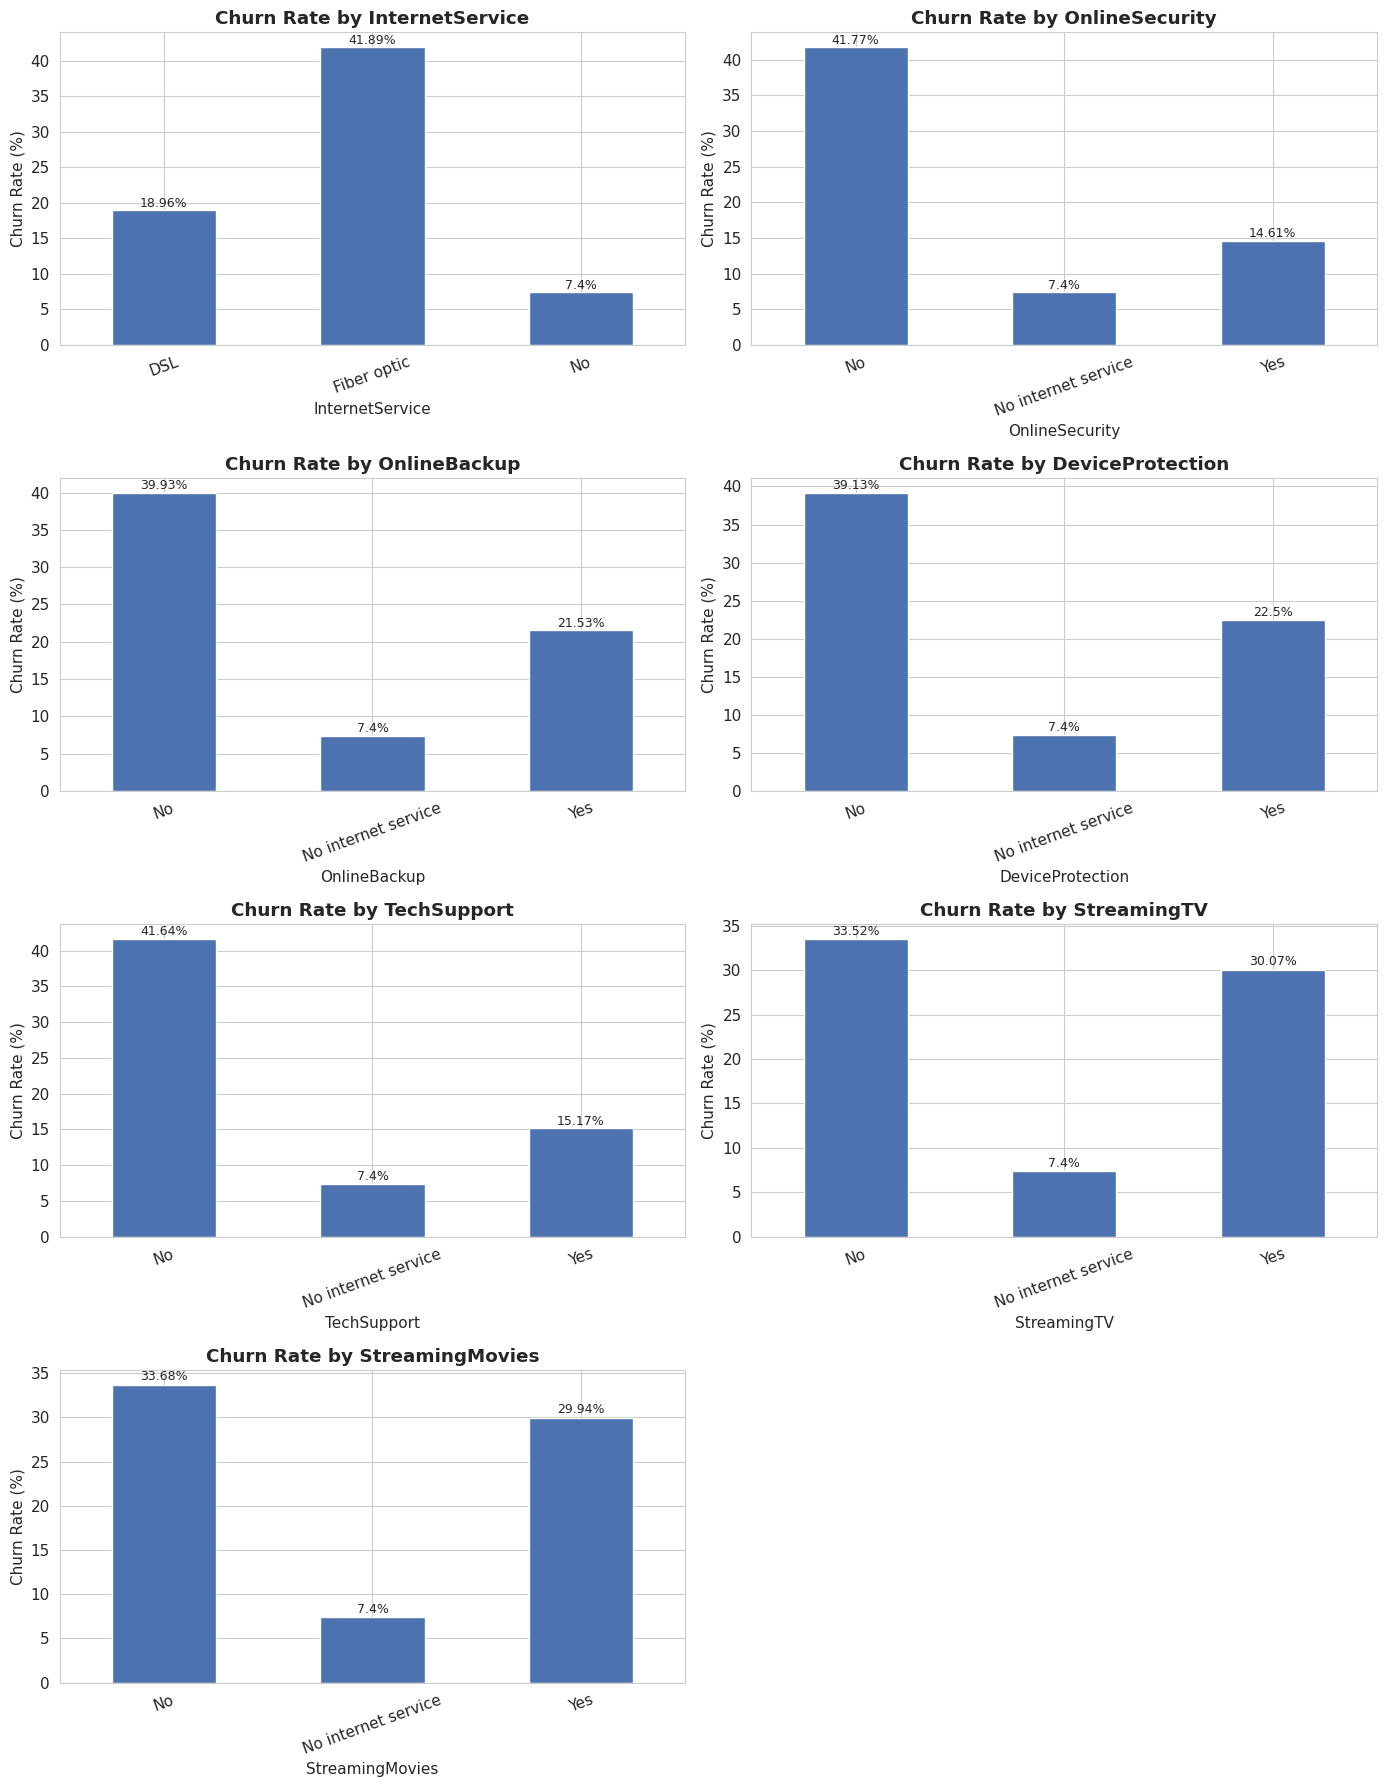


InternetService:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Churn, dtype: float64

TechSupport:
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

StreamingTV:
StreamingTV
No                     33.52
No internet service     7.40
Yes                    30.07
Name: Churn, dtype: float64

StreamingMovies:
StreamingMovies
No                     33.68
No internet service     7.40
Yes                    29.94
Name: Churn, dtype: float64


In [11]:
service_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    rate = df.groupby(col)['Churn'].mean().mul(100).round(2)
    rate.plot(kind='bar', ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(rate):
        axes[i].text(j, v + 0.5, f"{v}%", ha='center', fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

for col in service_cols:
    print(f"\n{col}:")
    print(df.groupby(col)['Churn'].mean().mul(100).round(2))


**Observation:** Customers with **Fiber optic** internet churn more than DSL or no-internet
customers. Across every add-on service (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
`TechSupport`), customers **without** the add-on churn noticeably more than those who have it —
`TechSupport` and `OnlineSecurity` show the largest gaps. Streaming services (`StreamingTV`,
`StreamingMovies`) show a much smaller difference between subscribers and non-subscribers.

**Business Interpretation:** Support-oriented add-ons (`TechSupport`, `OnlineSecurity`) appear to
act as retention anchors — customers who invested in them are stickier, possibly because they
receive more value/support or feel more "invested." Bundling these services into the base offer, or
proactively offering them to at-risk customers, is a concrete Task-5-worthy recommendation. The
elevated Fiber optic churn rate is worth flagging for a possible service-quality or price
investigation, since Fiber optic customers are also generally paying the highest charges (see
Section 12).

## 12. Charges Analysis

/tmp/ipykernel_570/899899274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_Label', y='MonthlyCharges', ax=axes[0], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_570/899899274.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_Label', y='TotalCharges', ax=axes[1], palette=['#4C72B0', '#DD8452'])


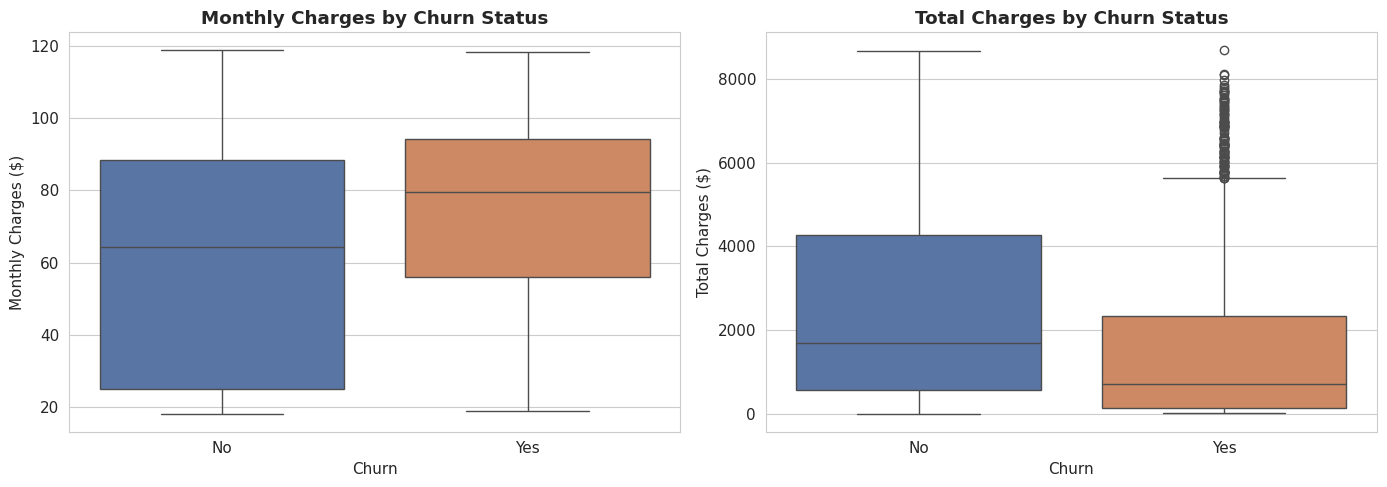

Monthly Charges by Churn status:
                  mean     50%        std
Churn_Label                              
No           61.265124  64.425  31.092648
Yes          74.441332  79.650  24.666053

Total Charges by Churn status:
                    mean       50%          std
Churn_Label                                    
No           2549.911442  1679.525  2329.954215
Yes          1531.796094   703.550  1890.822994


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn_Label', y='MonthlyCharges', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

sns.boxplot(data=df, x='Churn_Label', y='TotalCharges', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Total Charges by Churn Status', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Total Charges ($)')

plt.tight_layout()
plt.show()

print("Monthly Charges by Churn status:")
print(df.groupby('Churn_Label')['MonthlyCharges'].describe()[['mean', '50%', 'std']])
print("\nTotal Charges by Churn status:")
print(df.groupby('Churn_Label')['TotalCharges'].describe()[['mean', '50%', 'std']])


**Observation:** Churned customers have **higher median monthly charges** than retained
customers, but **lower total charges** — consistent with the tenure finding: churners leave early
(low tenure), so despite paying more per month they accumulate less total revenue before leaving.

**Business Interpretation:** High monthly bills combined with short tenure is the costliest churn
pattern for the business — these customers were paying a premium but leaving before the company
recouped acquisition cost. This is a key input for the customer-lifetime-value and high-risk-segment
work in Task 3 and Task 5.

## 13. Key Findings Summary

In [13]:
print("KEY EDA FINDINGS")
print("=" * 60)
print(f"1. Overall churn rate: {churn_rate:.2f}% ({churned} of {total_customers} customers)")
print(f"2. Highest-churn contract: {contract_churn.index[0]} "
      f"({contract_churn.iloc[0]['churn_rate_pct']}%)")
print(f"3. Lowest-churn contract: {contract_churn.index[-1]} "
      f"({contract_churn.iloc[-1]['churn_rate_pct']}%)")
print(f"4. Highest-churn payment method: {payment_churn.index[0]} "
      f"({payment_churn.iloc[0]['churn_rate_pct']}%)")
print(f"5. Churn rate in first tenure group (0-12 months): "
      f"{tenure_churn.loc['0-12','churn_rate_pct']}%")
print(f"6. Churn rate in longest tenure group (61-72 months): "
      f"{tenure_churn.loc['61-72','churn_rate_pct']}%")
print(f"7. Senior citizen churn rate: "
      f"{df.groupby('SeniorCitizen_Label')['Churn'].mean().mul(100).round(2)['Yes']}%")
print(f"8. Non-senior churn rate: "
      f"{df.groupby('SeniorCitizen_Label')['Churn'].mean().mul(100).round(2)['No']}%")


KEY EDA FINDINGS
1. Overall churn rate: 26.54% (1869 of 7043 customers)
2. Highest-churn contract: Month-to-month (42.71%)
3. Lowest-churn contract: Two year (2.83%)
4. Highest-churn payment method: Electronic check (45.29%)
5. Churn rate in first tenure group (0-12 months): 47.44%
6. Churn rate in longest tenure group (61-72 months): 6.61%
7. Senior citizen churn rate: 41.68%
8. Non-senior churn rate: 23.61%


## 14. EDA Conclusion

Nine key findings emerge from this analysis:

1. **Overall churn rate is 26.54%** — roughly 1 in 4 customers leave.
2. **Month-to-month contracts churn the most**; two-year contracts churn the least — contract
   length is a major controllable lever.
3. **Electronic check payers churn the most** among payment methods, likely due to lack of autopay
   commitment.
4. **The first 12 months of tenure is the highest-risk period**; churn falls steadily as tenure
   grows.
5. **Senior citizens churn more** than non-seniors.
6. **Customers without a partner or dependents churn more** — single-household customers are less
   "anchored."
7. **Fiber optic internet customers churn more** than DSL or no-internet customers.
8. **Missing support add-ons (`TechSupport`, `OnlineSecurity`) correlate with higher churn** —
   customers without these services are more likely to leave.
9. **Churners pay higher monthly charges but lower total charges** — a costly early-exit pattern for
   the business.

**Business Interpretation:** Churn is not random — it clusters around new, unsupported,
un-committed (month-to-month, manual-payment) customers on higher-priced plans. These findings
directly motivate the segmentation work in Task 3 and the retention strategies in Task 5.